# Lab 02 - End-to-End Machine Learning Project

Notebook này giữ đầy đủ flow của bài California Housing, nhưng phần code dùng lại được đã được refactor vào package `lab02` trong `src/lab02`.

## 0. Setup

In [52]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from packaging import version
from pandas.plotting import scatter_matrix
from scipy import stats
from scipy.stats import binom, expon, loguniform, randint
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from lab02.config import IMAGES_DIR, MODELS_DIR, PROJECT_ROOT, RANDOM_STATE
from lab02.data import (
    add_income_category,
    is_id_in_test_set,
    load_housing_data,
    shuffle_and_split_data,
    split_data_with_id_hash,
    split_features_labels,
    stratified_train_test_split,
)
from lab02.evaluation import evaluate_rmse, rmse_confidence_interval
from lab02.modeling import (
    build_linear_regression_pipeline,
    build_random_forest_pipeline,
    build_tree_regression_pipeline,
    cross_validate_rmse,
    load_model,
    random_search_random_forest,
    save_model,
)
from lab02.preprocessing import build_preprocessing_pipeline, column_ratio, ratio_pipeline
from lab02.transformers import ClusterSimilarity, FeatureFromRegressor, StandardScalerClone
from lab02.visualization import configure_matplotlib, save_fig

assert sys.version_info >= (3, 9)
assert version.parse(sklearn.__version__) >= version.parse("1.5")

np.random.seed(RANDOM_STATE)
configure_matplotlib()
PROJECT_ROOT

PosixPath('/Users/quangmanh/Project/lab02')

## 1. Get The Data

In [4]:
housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


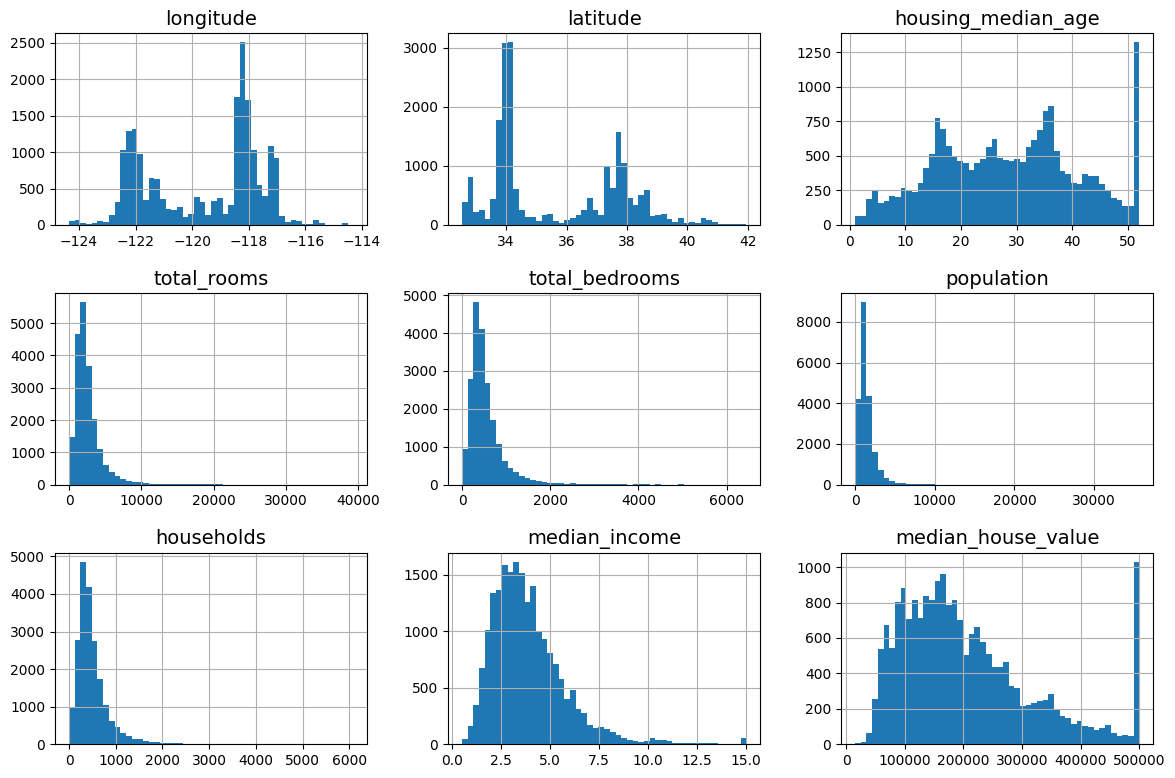

In [8]:
housing.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")
plt.show()

## 2. Create A Test Set

In [9]:
train_set, test_set = shuffle_and_split_data(housing, test_ratio=0.2, random_state=RANDOM_STATE)
len(train_set), len(test_set)

(16512, 4128)

In [10]:
housing_with_id = housing.reset_index()
train_set_hash, test_set_hash = split_data_with_id_hash(housing_with_id, 0.2, "index")
len(train_set_hash), len(test_set_hash)

(16512, 4128)

In [11]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set_hash, test_set_hash = split_data_with_id_hash(housing_with_id, 0.2, "id")
len(train_set_hash), len(test_set_hash)

(16322, 4318)

In [12]:
train_set_random, test_set_random = train_test_split(housing, test_size=0.2, random_state=RANDOM_STATE)
test_set_random["total_bedrooms"].isnull().sum()

np.int64(44)

In [13]:
sample_size = 1000
ratio_female = 0.511
proba_too_small = binom(sample_size, ratio_female).cdf(485 - 1)
proba_too_large = 1 - binom(sample_size, ratio_female).cdf(535)
proba_too_small + proba_too_large

np.float64(0.10736798530930358)

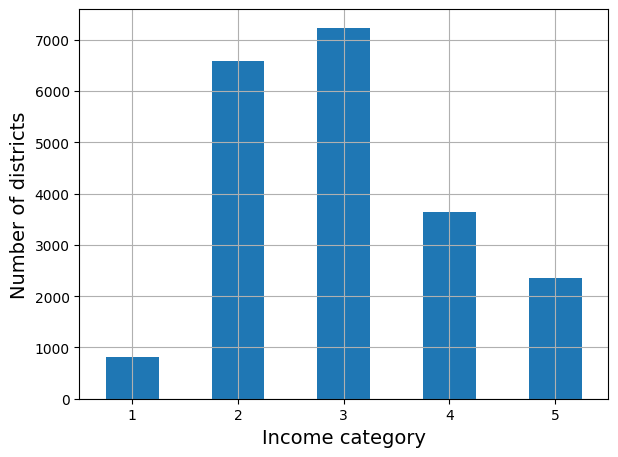

In [14]:
housing_with_income_cat = add_income_category(housing)
housing_with_income_cat["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
save_fig("housing_income_cat_bar_plot")
plt.show()

In [15]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

strat_train_set, strat_test_set = stratified_train_test_split(housing)
strat_test_with_income_cat = add_income_category(strat_test_set)
random_test_with_income_cat = add_income_category(test_set_random)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing_with_income_cat),
    "Stratified %": income_cat_proportions(strat_test_with_income_cat),
    "Random %": income_cat_proportions(random_test_with_income_cat),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = compare_props["Stratified %"] / compare_props["Overall %"] - 1
compare_props["Rand. Error %"] = compare_props["Random %"] / compare_props["Overall %"] - 1
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


## 3. Discover And Visualize The Data

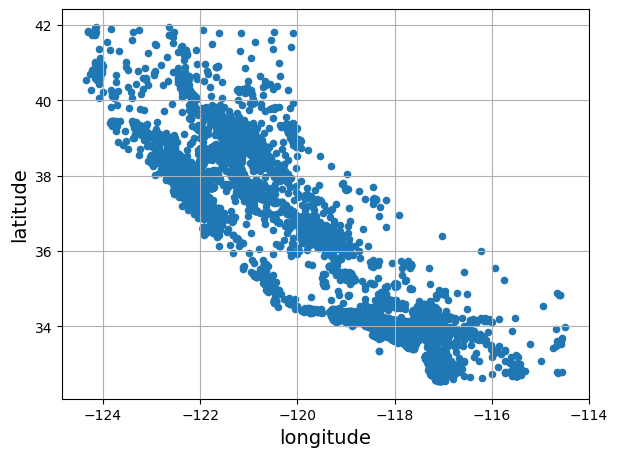

In [16]:
housing_explore = strat_train_set.copy()
housing_explore.plot(kind="scatter", x="longitude", y="latitude", grid=True)
save_fig("bad_visualization_plot")
plt.show()

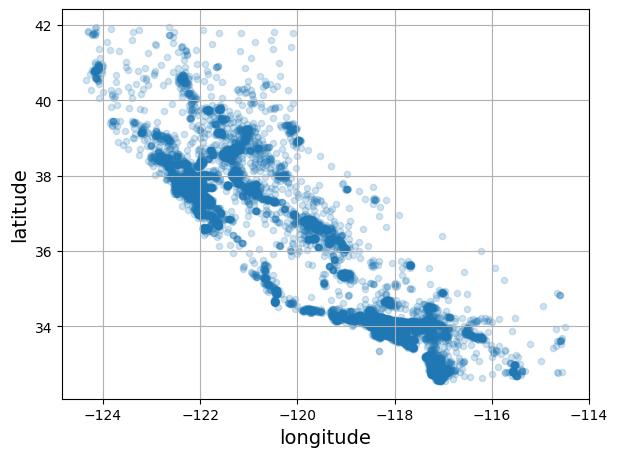

In [17]:
housing_explore.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
save_fig("better_visualization_plot")
plt.show()

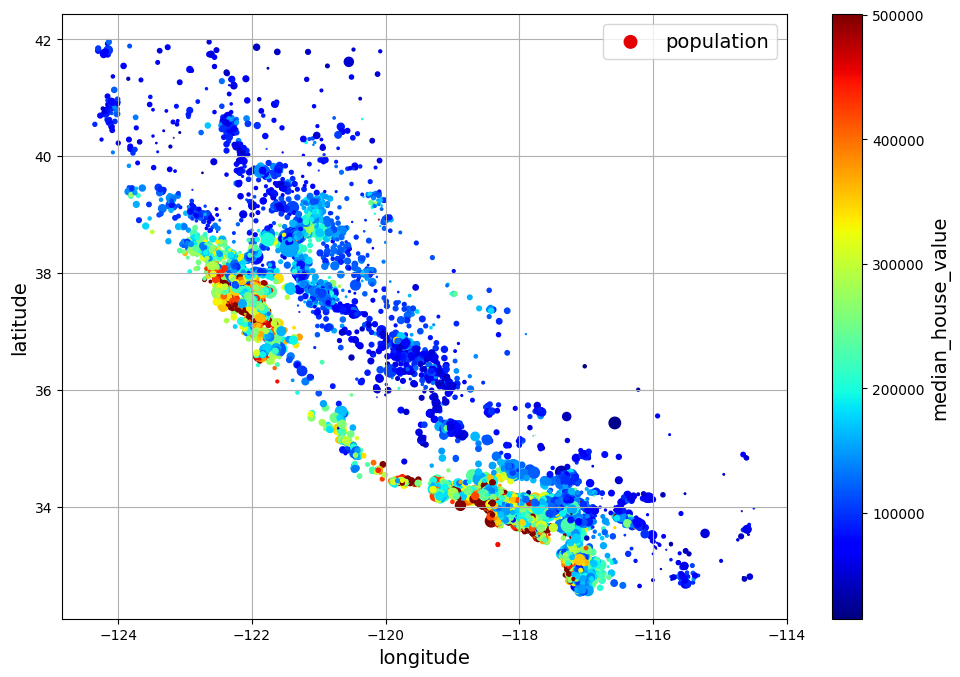

In [18]:
housing_explore.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    grid=True,
    s=housing_explore["population"] / 100,
    label="population",
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    legend=True,
    sharex=False,
    figsize=(10, 7),
)
save_fig("housing_prices_scatterplot")
plt.show()

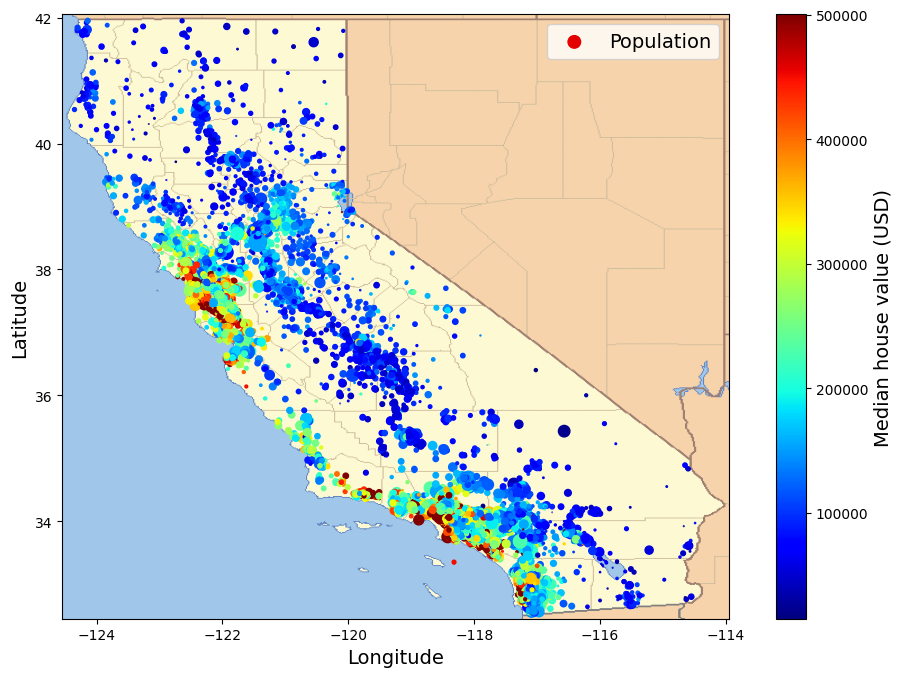

In [19]:
filename = "california.png"
california_path = IMAGES_DIR / filename
if not california_path.is_file():
    import urllib.request
    url = "https://github.com/ageron/handson-ml3/raw/main/images/end_to_end_project/california.png"
    urllib.request.urlretrieve(url, california_path)

housing_renamed = housing_explore.rename(columns={
    "latitude": "Latitude",
    "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (USD)",
})
housing_renamed.plot(
    kind="scatter",
    x="Longitude",
    y="Latitude",
    s=housing_renamed["Population"] / 100,
    label="Population",
    c="Median house value (USD)",
    cmap="jet",
    colorbar=True,
    legend=True,
    sharex=False,
    figsize=(10, 7),
)
california_img = plt.imread(california_path)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)
save_fig("california_housing_prices_plot")
plt.show()

## 4. Look For Correlations

In [20]:
corr_matrix = housing_explore.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

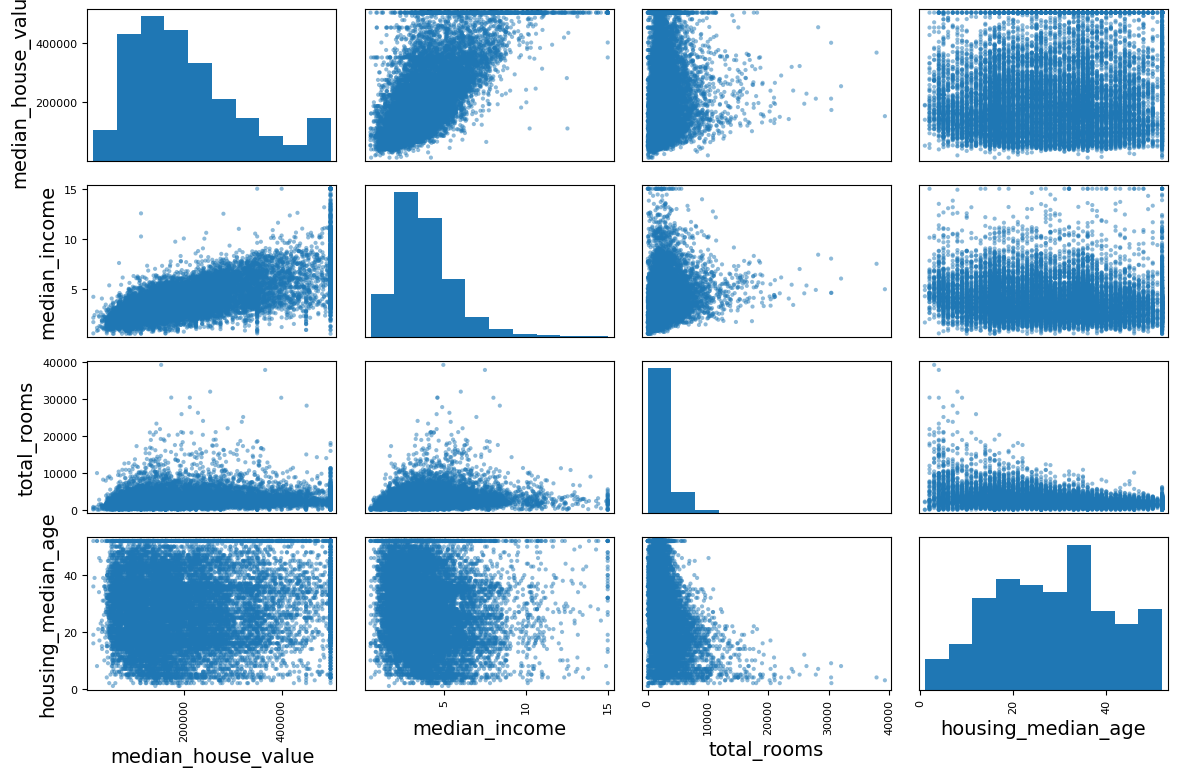

In [21]:
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing_explore[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")
plt.show()

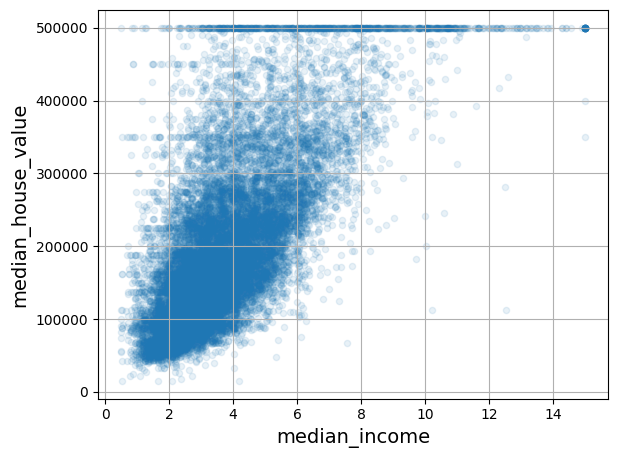

In [22]:
housing_explore.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.1,
    grid=True,
)
save_fig("income_vs_house_value_scatterplot")
plt.show()

## 5. Experiment With Attribute Combinations

In [23]:
housing_explore["rooms_per_house"] = housing_explore["total_rooms"] / housing_explore["households"]
housing_explore["bedrooms_ratio"] = housing_explore["total_bedrooms"] / housing_explore["total_rooms"]
housing_explore["people_per_house"] = housing_explore["population"] / housing_explore["households"]

corr_matrix = housing_explore.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

## 6. Prepare The Data For Machine Learning

In [24]:
housing_train, housing_labels = split_features_labels(strat_train_set)
housing_test, housing_test_labels = split_features_labels(strat_test_set)
housing_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN


In [25]:
null_rows_idx = housing_train.isnull().any(axis=1)
housing_train.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


In [26]:
housing_option1 = housing_train.copy()
housing_option1.dropna(subset=["total_bedrooms"], inplace=True)
housing_option1.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [27]:
housing_option2 = housing_train.copy()
housing_option2.drop("total_bedrooms", axis=1, inplace=True)
housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN


In [28]:
housing_option3 = housing_train.copy()
median = housing_train["total_bedrooms"].median()
housing_option3["total_bedrooms"] = housing_option3["total_bedrooms"].fillna(median)
housing_option3.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020,<1H OCEAN


In [29]:
imputer = SimpleImputer(strategy="median")
housing_num = housing_train.select_dtypes(include=[np.number])
imputer.fit(housing_num)
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


In [30]:
isolation_forest = IsolationForest(random_state=RANDOM_STATE)
outlier_pred = isolation_forest.fit_predict(X)
pd.Series(outlier_pred).value_counts()

 1    14448
-1     2064
Name: count, dtype: int64

### Categorical Attributes

In [31]:
housing_cat = housing_train[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [32]:
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:8], ordinal_encoder.categories_

(array([[3.],
        [0.],
        [1.],
        [1.],
        [4.],
        [1.],
        [0.],
        [3.]]),
 [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
        dtype=object)])

In [33]:
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
pd.DataFrame(
    housing_cat_1hot[:8],
    columns=cat_encoder.get_feature_names_out(),
    index=housing_cat.index[:8],
)

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,0.0,0.0,0.0,1.0,0.0
14973,1.0,0.0,0.0,0.0,0.0
3785,0.0,1.0,0.0,0.0,0.0
14689,0.0,1.0,0.0,0.0,0.0
20507,0.0,0.0,0.0,0.0,1.0
1286,0.0,1.0,0.0,0.0,0.0
18078,1.0,0.0,0.0,0.0,0.0
4396,0.0,0.0,0.0,1.0,0.0


### Feature Scaling And Custom Transformers

In [34]:
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)
housing_num_min_max_scaled[:3], housing_num_std_scaled[:3]

(array([[-0.60851927,  0.11702128,  1.        , -0.83117147, -0.64116605,
         -0.80701754, -0.61433638, -0.7794789 ],
        [ 0.21095335, -0.66170213,  0.52941176, -0.90014752, -0.88629409,
         -0.91866029, -0.86708979, -0.22929339],
        [-0.51926978,  0.23617021,  0.25490196, -0.94501246, -0.93042358,
         -0.93141946, -0.92458466, -0.73336919]]),
 array([[-1.42303652,  1.0136059 ,  1.86111875,  0.31191221,  1.35909429,
          0.13746004,  1.39481249, -0.93649149],
        [ 0.59639445, -0.702103  ,  0.90762971, -0.30861991, -0.43635598,
         -0.69377062, -0.37348471,  1.17194198],
        [-1.2030985 ,  1.27611874,  0.35142777, -0.71224036, -0.75958421,
         -0.78876841, -0.77572662, -0.75978881]]))

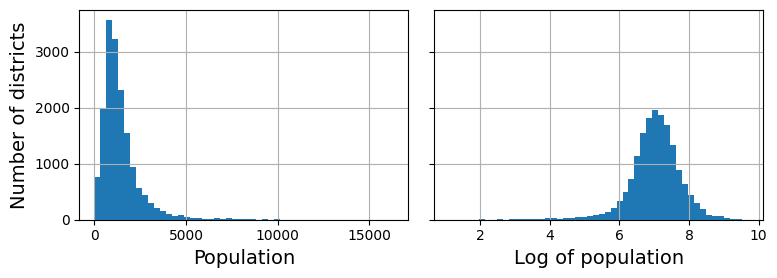

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing_train["population"].hist(ax=axs[0], bins=50)
housing_train["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

In [36]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=RANDOM_STATE)
similarities = cluster_simil.fit_transform(housing_train[["latitude", "longitude"]])
similarities[:3].round(2)

array([[0.  , 0.97, 0.  , 0.  , 0.  , 0.08, 0.  , 0.  , 0.13, 0.57],
       [0.12, 0.  , 0.98, 0.03, 0.  , 0.  , 0.  , 0.54, 0.  , 0.  ],
       [0.  , 0.75, 0.  , 0.  , 0.  , 0.44, 0.  , 0.  , 0.27, 0.28]])

In [37]:
preprocessing = build_preprocessing_pipeline()
housing_prepared = preprocessing.fit_transform(housing_train)
housing_prepared.shape

(16512, 24)

In [38]:
preprocessing.get_feature_names_out()[:20]

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__cluster_0_similarity',
       'geo__cluster_1_similarity', 'geo__cluster_2_similarity',
       'geo__cluster_3_similarity', 'geo__cluster_4_similarity',
       'geo__cluster_5_similarity', 'geo__cluster_6_similarity',
       'geo__cluster_7_similarity', 'geo__cluster_8_similarity',
       'geo__cluster_9_similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND'], dtype=object)

## 7. Select And Train Models

In [39]:
lin_reg = build_linear_regression_pipeline()
lin_reg.fit(housing_train, housing_labels)

sample_predictions = lin_reg.predict(housing_train.iloc[:5])
pd.DataFrame({"prediction": sample_predictions, "label": housing_labels.iloc[:5].values})

,prediction,label
0,242761.812857,458300.0
1,375862.785030,483800.0
2,127480.982734,101700.0
3,99355.302576,96100.0
4,324610.742241,361800.0


In [40]:
lin_rmse = evaluate_rmse(lin_reg, housing_train, housing_labels)
lin_rmse

68647.95686706656

In [41]:
tree_reg = build_tree_regression_pipeline()
tree_reg.fit(housing_train, housing_labels)
tree_rmse = evaluate_rmse(tree_reg, housing_train, housing_labels)
tree_rmse

0.0

In [42]:
tree_rmses = cross_validate_rmse(tree_reg, housing_train, housing_labels, cv=10)
pd.Series(tree_rmses).describe()

count       10.000000
mean     67153.318273
std       1963.580924
min      63925.253106
25%      66083.277180
50%      66795.829871
75%      68074.018403
max      70664.635833
dtype: float64

In [43]:
forest_reg = build_random_forest_pipeline()
forest_rmses = cross_validate_rmse(forest_reg, housing_train, housing_labels, cv=10)
pd.Series(forest_rmses).describe()

count       10.000000
mean     47002.931706
std       1048.451340
min      45667.064036
25%      46494.358345
50%      47093.173938
75%      47274.873814
max      49354.705514
dtype: float64

## 8. Fine-Tune The Model

In [44]:
full_pipeline = build_random_forest_pipeline()
param_grid = [
    {"preprocessing__geo__n_clusters": [5, 8, 10], "random_forest__max_features": [4, 6, 8]},
    {"preprocessing__geo__n_clusters": [10, 15], "random_forest__max_features": [6, 8, 10]},
]

grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
)
grid_search.fit(housing_train, housing_labels)
-grid_search.best_score_, grid_search.best_params_

(np.float64(43954.272463231515),
 {'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6})

In [45]:
rnd_search = random_search_random_forest(
    housing_train,
    housing_labels,
    n_iter=10,
    cv=3,
)
-rnd_search.best_score_, rnd_search.best_params_

(np.float64(41983.41256325975),
 {'preprocessing__geo__n_clusters': 45, 'random_forest__max_features': 9})

In [46]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False)[[
    "mean_test_score",
    "param_preprocessing__geo__n_clusters",
    "param_random_forest__max_features",
]].head()

,mean_test_score,param_preprocessing__geo__n_clusters,param_random_forest__max_features
1,-41983.412563,45,9
8,-42340.960636,32,7
5,-42767.043621,42,4
0,-42769.045978,41,16
2,-43120.703464,23,8


In [47]:
final_model = rnd_search.best_estimator_
feature_importances = final_model["random_forest"].feature_importances_
sorted(
    zip(feature_importances, final_model["preprocessing"].get_feature_names_out()),
    reverse=True,
)[:20]

[(np.float64(0.19087378222226137), 'log__median_income'),
 (np.float64(0.07625632853052883), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.06365028932207333), 'bedrooms__ratio'),
 (np.float64(0.057834740538722625), 'rooms_per_house__ratio'),
 (np.float64(0.04907003277818634), 'people_per_house__ratio'),
 (np.float64(0.038165489600129165), 'geo__cluster_3_similarity'),
 (np.float64(0.025700861301416925), 'geo__cluster_22_similarity'),
 (np.float64(0.02186407550147744), 'geo__cluster_17_similarity'),
 (np.float64(0.021818299311019237), 'geo__cluster_6_similarity'),
 (np.float64(0.018249904787654904), 'geo__cluster_2_similarity'),
 (np.float64(0.017263517651784216), 'geo__cluster_32_similarity'),
 (np.float64(0.015649725317935348), 'geo__cluster_18_similarity'),
 (np.float64(0.015236556682888558), 'geo__cluster_40_similarity'),
 (np.float64(0.014160249342841777), 'geo__cluster_43_similarity'),
 (np.float64(0.014113856232349186), 'geo__cluster_7_similarity'),
 (np.float64(0.01396840676968

## 9. Evaluate On The Test Set

In [48]:
final_predictions = final_model.predict(housing_test)
final_rmse = root_mean_squared_error(housing_test_labels, final_predictions)
final_rmse

41536.20954091729

In [53]:
rmse_lower, rmse_upper = rmse_confidence_interval(final_predictions, housing_test_labels)
rmse_lower, rmse_upper

AttributeError: module 'scipy.stats' has no attribute 'quantile'

In [ ]:
model_path = save_model(final_model, "california_housing_model.pkl")
model_path

In [ ]:
final_model_reloaded = load_model(model_path)
new_data = housing_train.iloc[:5]
final_model_reloaded.predict(new_data)

## 10. Exercises / Optional Experiments

Các cell dưới đây giữ lại hướng bài tập chính. Một vài cell có thể chạy lâu hơn vì dùng cross-validation hoặc randomized search.

In [ ]:
svr_param_grid = [
    {"svr__kernel": ["linear"], "svr__C": [10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0, 30000.0]},
    {"svr__kernel": ["rbf"], "svr__C": [1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0], "svr__gamma": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]},
]

svr_pipeline = Pipeline([("preprocessing", build_preprocessing_pipeline()), ("svr", SVR())])
svr_grid_search = GridSearchCV(
    svr_pipeline,
    svr_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
)
svr_grid_search.fit(housing_train.iloc[:5000], housing_labels.iloc[:5000])
-svr_grid_search.best_score_, svr_grid_search.best_params_

In [ ]:
svr_param_distribs = {
    "svr__kernel": ["linear", "rbf"],
    "svr__C": loguniform(20, 200_000),
    "svr__gamma": expon(scale=1.0),
}

svr_rnd_search = RandomizedSearchCV(
    svr_pipeline,
    param_distributions=svr_param_distribs,
    n_iter=50,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
)
svr_rnd_search.fit(housing_train.iloc[:5000], housing_labels.iloc[:5000])
-svr_rnd_search.best_score_, svr_rnd_search.best_params_

In [ ]:
selector_pipeline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline()),
    ("selector", SelectFromModel(RandomForestRegressor(random_state=RANDOM_STATE), threshold=0.005)),
    ("svr", SVR(
        C=svr_rnd_search.best_params_["svr__C"],
        gamma=svr_rnd_search.best_params_["svr__gamma"],
        kernel=svr_rnd_search.best_params_["svr__kernel"],
    )),
])

selector_rmses = -cross_val_score(
    selector_pipeline,
    housing_train.iloc[:5000],
    housing_labels.iloc[:5000],
    scoring="neg_root_mean_squared_error",
    cv=3,
)
pd.Series(selector_rmses).describe()

In [ ]:
knn_reg = KNeighborsRegressor(n_neighbors=3, weights="distance")
knn_transformer = FeatureFromRegressor(knn_reg)
geo_features = housing_train[["latitude", "longitude"]]
knn_transformer.fit_transform(geo_features, housing_labels)[:5]

In [ ]:
transformers = [(name, clone(transformer), columns) for name, transformer, columns in build_preprocessing_pipeline().transformers]
geo_index = [name for name, _, _ in transformers].index("geo")
transformers[geo_index] = ("geo", knn_transformer, ["latitude", "longitude"])
new_geo_preprocessing = ColumnTransformer(transformers)

new_geo_pipeline = Pipeline([
    ("preprocessing", new_geo_preprocessing),
    ("svr", SVR(
        C=svr_rnd_search.best_params_["svr__C"],
        gamma=svr_rnd_search.best_params_["svr__gamma"],
        kernel=svr_rnd_search.best_params_["svr__kernel"],
    )),
])

new_pipe_rmses = -cross_val_score(
    new_geo_pipeline,
    housing_train.iloc[:5000],
    housing_labels.iloc[:5000],
    scoring="neg_root_mean_squared_error",
    cv=3,
)
pd.Series(new_pipe_rmses).describe()

In [ ]:
X_scaler_test = np.random.rand(1000, 3)
scaler = StandardScalerClone()
X_scaled = scaler.fit_transform(X_scaler_test)
X_back = scaler.inverse_transform(X_scaled)

assert np.allclose(X_scaled, (X_scaler_test - X_scaler_test.mean(axis=0)) / X_scaler_test.std(axis=0))
assert np.allclose(X_scaler_test, X_back)
assert np.all(scaler.get_feature_names_out() == ["x0", "x1", "x2"])
"StandardScalerClone works"